In [ ]:
from google.colab import files
uploaded = files.upload()

Saving abnormal.csv to abnormal (2).csv
Saving normal.csv to normal (2).csv


In [ ]:
import pandas as pd

normal = pd.read_csv("normal.csv")
abnormal = pd.read_csv("abnormal.csv")

print(normal.head())
print(abnormal.head())

   time_ms    ax    ay    az   gx   gy   gz  temp
0      486  1.96  1.96  9.81  0.0  0.0  0.0  24.0
1      543  1.96  1.96  9.81  0.0  0.0  0.0  24.0
2      600  1.96  1.96  9.81  0.0  0.0  0.0  24.0
3      657  1.96  1.96  9.81  0.0  0.0  0.0  24.0
4      714  1.96  1.96  9.81  0.0  0.0  0.0  24.0
   time_ms    ax    ay    az   gx   gy   gz  temp
0      486 -6.86 -8.83  9.81  0.0  0.0  0.0  24.0
1      544 -6.86 -8.83  9.81  0.0  0.0  0.0  24.0
2      601 -6.86 -8.83  9.81  0.0  0.0  0.0  24.0
3      658 -6.86 -8.83  9.81  0.0  0.0  0.0  24.0
4      715 -6.86 -8.83  9.81  0.0  0.0  0.0  24.0


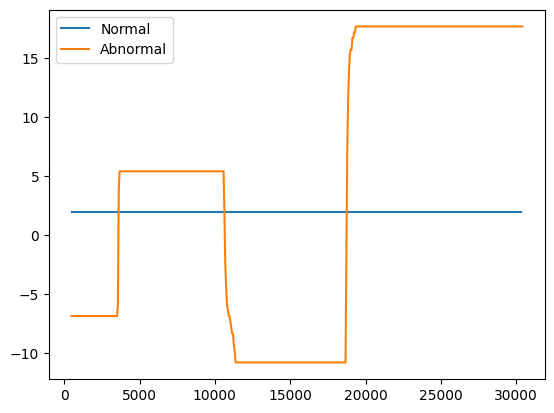

In [ ]:
import matplotlib.pyplot as plt

plt.plot(normal["time_ms"], normal["ax"], label="Normal")
plt.plot(abnormal["time_ms"], abnormal["ax"], label="Abnormal")
plt.legend()
plt.show()

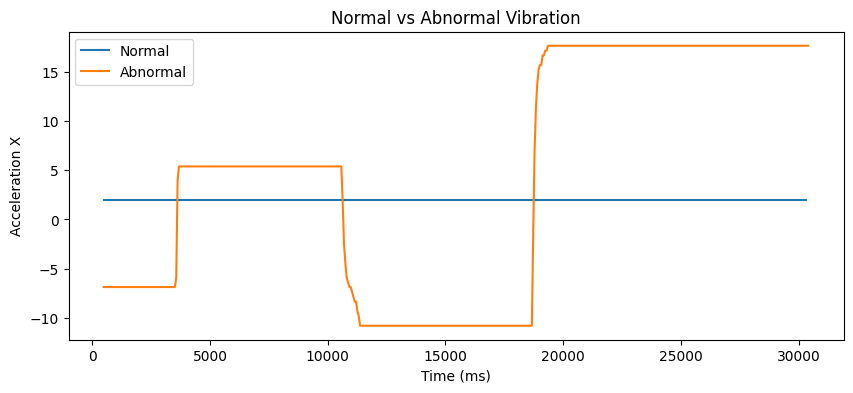

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(normal["time_ms"], normal["ax"], label="Normal")
plt.plot(abnormal["time_ms"], abnormal["ax"], label="Abnormal")
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration X")
plt.title("Normal vs Abnormal Vibration")
plt.legend()
plt.show()

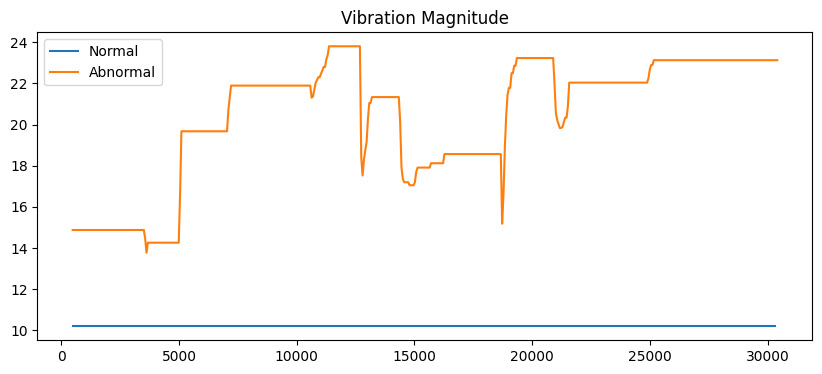

In [ ]:
import numpy as np

normal["mag"] = np.sqrt(normal["ax"]**2 + normal["ay"]**2 + normal["az"]**2)
abnormal["mag"] = np.sqrt(abnormal["ax"]**2 + abnormal["ay"]**2 + abnormal["az"]**2)

plt.figure(figsize=(10,4))
plt.plot(normal["time_ms"], normal["mag"], label="Normal")
plt.plot(abnormal["time_ms"], abnormal["mag"], label="Abnormal")
plt.legend()
plt.title("Vibration Magnitude")
plt.show()

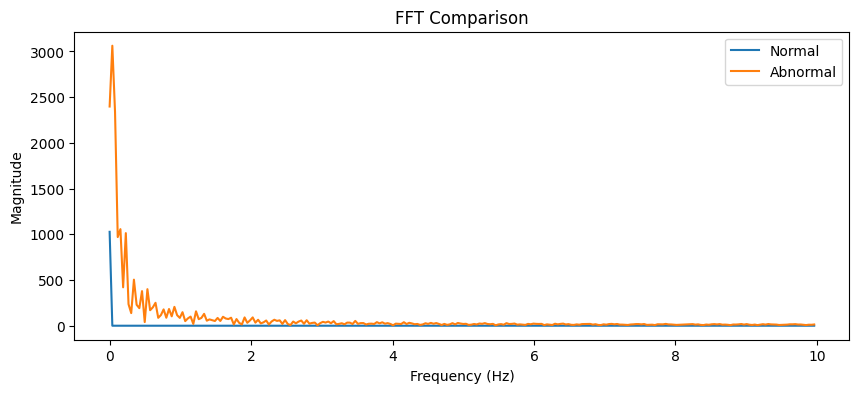

In [ ]:
signal_normal = normal["ax"].values
signal_abnormal = abnormal["ax"].values

dt = 0.05  # because delay(50 ms)

fft_normal = np.fft.fft(signal_normal)
fft_abnormal = np.fft.fft(signal_abnormal)

freq = np.fft.fftfreq(len(signal_normal), d=dt)

half = len(freq) // 2

plt.figure(figsize=(10,4))
plt.plot(freq[:half], np.abs(fft_normal[:half]), label="Normal")
plt.plot(freq[:half], np.abs(fft_abnormal[:half]), label="Abnormal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Comparison")
plt.legend()
plt.show()

In [ ]:
normal_rms = np.sqrt(np.mean(normal["ax"]**2))
abnormal_rms = np.sqrt(np.mean(abnormal["ax"]**2))

print("Normal RMS:", normal_rms)
print("Abnormal RMS:", abnormal_rms)

Normal RMS: 1.96
Abnormal RMS: 12.694913969161455
